In [2]:
# You must run this code and use this dataset for all questions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
num_students = 50

# Student data
student_ids = np.arange(201, 201 + num_students)
student_ages = np.random.randint(15, 22, num_students)
student_scores = np.random.randint(40, 100, num_students)
student_attendance = np.random.randint(60, 100, num_students)  # percentage

departments_list = [
    "Science",
    "Commerce",
    "Arts",
    "Computer Science",
    "Mathematics",
    "English",
    "Physics",
    "Chemistry",
    "Biology",
    "Economics"
]

student_departments = np.random.choice(departments_list, num_students)

grade_conditions = [
    student_scores >= 80,
    (student_scores >= 65) & (student_scores < 80),
    (student_scores >= 50) & (student_scores < 65),
    student_scores < 50
]
grade_values = ["A", "B", "C", "F"]
student_grades = np.select(grade_conditions, grade_values, default="F")

# Create DataFrame
data = pd.DataFrame({
    "student_id": student_ids,
    "student_age": student_ages,
    "score": student_scores,
    "attendance": student_attendance,
    "department": student_departments,
    "grade": student_grades
})

# Save dataset
data.to_csv("school_data.csv", index=False)

In [3]:
score_array = data['score']
attendance_array = data['attendance']
print('Score array: ', score_array)
print(f'Data type of Score array: {score_array.dtype}')
print(f'number of dimensions of score array : {score_array.ndim}')
print(f'Shape of Score array: {score_array.shape}')
print(f'Total number of elements of Score array: {score_array.size}')

print('Attendance array: ', attendance_array)
print(f'Data type of Attendance array: {attendance_array.dtype}')
print(f'number of dimensions of attendance array : {attendance_array.ndim}')
print(f'Shape of Attendance array: {attendance_array.shape}')
print(f'Total number of elements of Attendance array: {attendance_array.size}')

Score array:  0     76
1     90
2     46
3     60
4     48
5     78
6     57
7     43
8     64
9     99
10    53
11    89
12    97
13    48
14    65
15    92
16    41
17    59
18    67
19    86
20    99
21    46
22    83
23    47
24    86
25    74
26    53
27    56
28    75
29    89
30    79
31    43
32    41
33    45
34    93
35    81
36    43
37    93
38    68
39    57
40    65
41    83
42    73
43    49
44    75
45    53
46    70
47    87
48    54
49    47
Name: score, dtype: int32
Data type of Score array: int32
number of dimensions of score array : 1
Shape of Score array: (50,)
Total number of elements of Score array: 50
Attendance array:  0     73
1     82
2     99
3     80
4     75
5     77
6     83
7     85
8     84
9     88
10    74
11    60
12    84
13    66
14    68
15    83
16    60
17    67
18    83
19    70
20    76
21    67
22    94
23    94
24    92
25    64
26    98
27    87
28    66
29    68
30    67
31    71
32    93
33    92
34    82
35    83
36    96
37    94
38   

# Question 02: [ Marks 10 ]

## Using NumPy functions on :

* Find the maximum and minimum score
* Calculate the average score
* Calculate the average attendance

Then, extract students who:

* Have a score greater than the average score

Print:

* The filtered score array

In [4]:
attendance_array = np.array(data['attendance'])

max_score = np.max(score_array)
avg_score =np.average(score_array)
avg_atten = np.average(attendance_array)

filtered_score = score_array[score_array>avg_score]
print(filtered_score)

0     76
1     90
5     78
9     99
11    89
12    97
15    92
19    86
20    99
22    83
24    86
25    74
28    75
29    89
30    79
34    93
35    81
37    93
38    68
41    83
42    73
44    75
46    70
47    87
Name: score, dtype: int32


In [5]:
avg_score

np.float64(67.3)

In [6]:
data

,student_id,student_age,score,attendance,department,grade
0,201,21,76,73,Physics,B
1,202,18,90,82,Physics,A
2,203,19,46,99,Biology,F
3,204,21,60,80,Economics,C
4,205,17,48,75,Economics,F
5,206,19,78,77,Arts,B
6,207,19,57,83,Physics,C
7,208,21,43,85,Science,F
8,209,16,64,84,Computer Science,C
9,210,17,99,88,Computer Science,A


# Question 03: [Marks 10]

##
Load the school_data.csv file into a Pandas DataFrame.

* Display the first 3 rows
* Show dataset information using .info()
* Display summary statistics using .describe()

Then filter the dataset to include only:

* student_id, student_age, department, grade

Select students whose age is between 16 and 20, sort them by student_id, and display the last 3 rows of the result.


In [7]:
data.head()

,student_id,student_age,score,attendance,department,grade
0,201,21,76,73,Physics,B
1,202,18,90,82,Physics,A
2,203,19,46,99,Biology,F
3,204,21,60,80,Economics,C
4,205,17,48,75,Economics,F


In [8]:
data

,student_id,student_age,score,attendance,department,grade
0,201,21,76,73,Physics,B
1,202,18,90,82,Physics,A
2,203,19,46,99,Biology,F
3,204,21,60,80,Economics,C
4,205,17,48,75,Economics,F
5,206,19,78,77,Arts,B
6,207,19,57,83,Physics,C
7,208,21,43,85,Science,F
8,209,16,64,84,Computer Science,C
9,210,17,99,88,Computer Science,A


# Question 04: [ Marks 10 ]

##
Using .loc:

* Increase the score by 10% for students in "Computer Science" and "Mathematics" departments
* Increase the score by 5% for all other departments
* Cap the score at 100 (no score should exceed 100 after the raise)

Then print a DataFrame that includes:

* student_id, department, previous_score, new_score, score_increase

In [9]:
condition = data['department'].isin(['Computer Science','Mathmatics'])

new_score = data['score'].copy()


new_score[condition] = data.loc[condition, 'score'] * 1.10
new_score[~condition]= data.loc[~condition,'score'] * 1.05

condition_2 = new_score >= 100
new_score[condition_2] = data.loc[condition_2,'score'] =100



new_df = pd.DataFrame({ 
    'student_id': data['student_id'],
    'Department':data['department'],
    'Previous_score':data['score'],
    'new_score':new_score


    }
)

new_df

C:\Users\sumon\AppData\Local\Temp\ipykernel_4892\1247791937.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 70.4 108.9  52.8  91.3  47.3  77. ]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  new_score[condition] = data.loc[condition, 'score'] * 1.10


,student_id,Department,Previous_score,new_score
0,201,Physics,76,79.80
1,202,Physics,90,94.50
2,203,Biology,46,48.30
3,204,Economics,60,63.00
4,205,Economics,48,50.40
5,206,Arts,78,81.90
6,207,Physics,57,59.85
7,208,Science,43,45.15
8,209,Computer Science,64,70.40
9,210,Computer Science,100,100.00


# Question 05: [ Marks 10 ]

Using Matplotlib, create a bar chart that shows the average score per department.

* X-axis: Department names
* Y-axis: Average score
* Add a title: "Average Score by Department"
* Display the chart

Text(0.5, 1.0, 'Average score by department')

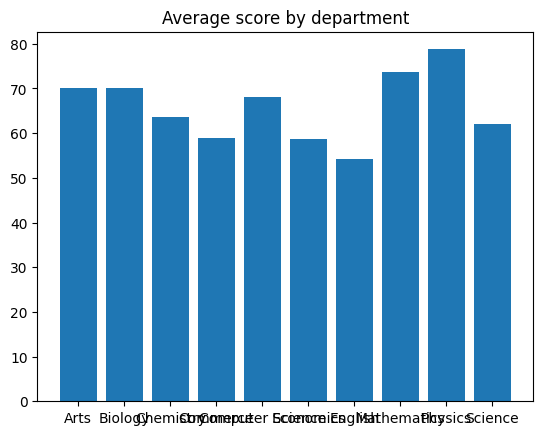

In [10]:
department = data.groupby('department')
department_2 = data.groupby('department').size()
av_per_dept=[]
for key, value in department:
    av_per_dept.append(np.average(value['score']))


plt.bar(department_2.index, av_per_dept)
plt.title('Average score by department')

# Question 06: [ Marks 10 ]

Using Matplotlib, create a histogram of the score column.

* Use 10 bins
* Add a title: "Distribution of Student Scores"
* Label X-axis as "Score" and Y-axis as "Number of Students"
* Display the chart

Text(0, 0.5, 'Number of Students')

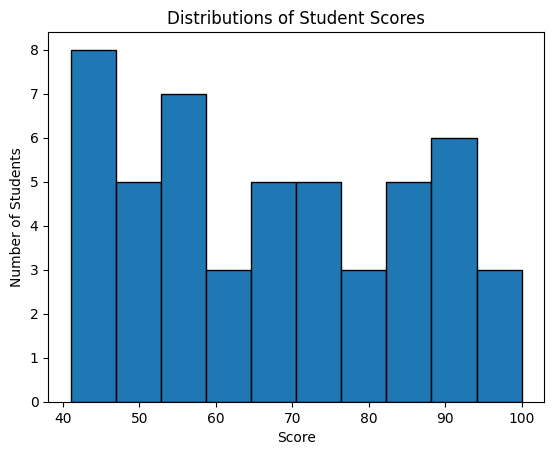

In [11]:
plt.title('Distributions of Student Scores')
plt.hist(data['score'], bins=10, edgecolor='Black')
plt.xlabel('Score')
plt.ylabel('Number of Students')

# Question 07: [ Marks 10 ]

Using Matplotlib, create a scatter plot to visualize the relationship between attendance and score.

* X-axis: Attendance (%)
* Y-axis: Score
* Add a title: "Attendance vs Score"
* Label both axes properly
* Display the chart

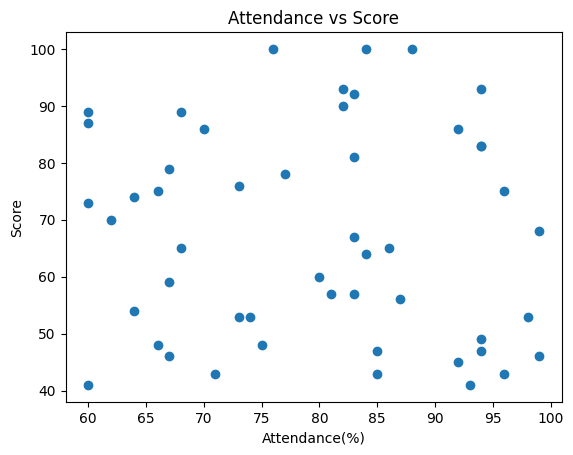

In [12]:
plt.title('Attendance vs Score')
plt.xlabel('Attendance(%)')
plt.ylabel('Score')
plt.scatter(data['attendance'],data['score'])

# Question 08: [ Marks 10 ]

Using Seaborn, create a boxplot that shows the distribution of score across different grade categories.

* X-axis: Grade
* Y-axis: Score
* Add a title: "Score Distribution by Grade"
* Display the chart

<Axes: xlabel='grade', ylabel='score'>

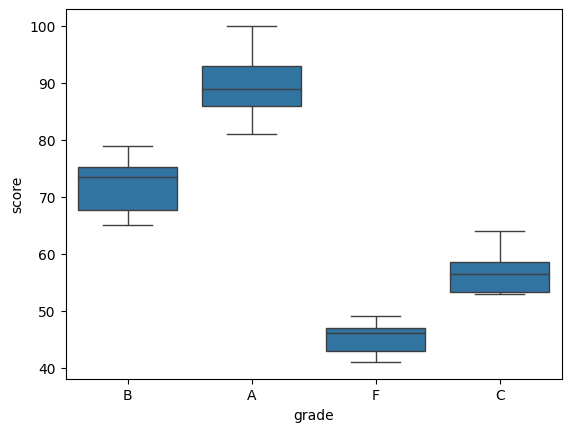

In [13]:
#sns.boxplot(data=df, x="category_column", y="numeric_column", hue="sub_category")
sns.boxplot(data=data,x='grade',y='score')

# Question 09: [ Marks 10 ]

Using Seaborn, create a countplot showing the number of students in each department.

* Add a title: "Number of Students per Department"
* Display the chart

<Axes: xlabel='department', ylabel='count'>

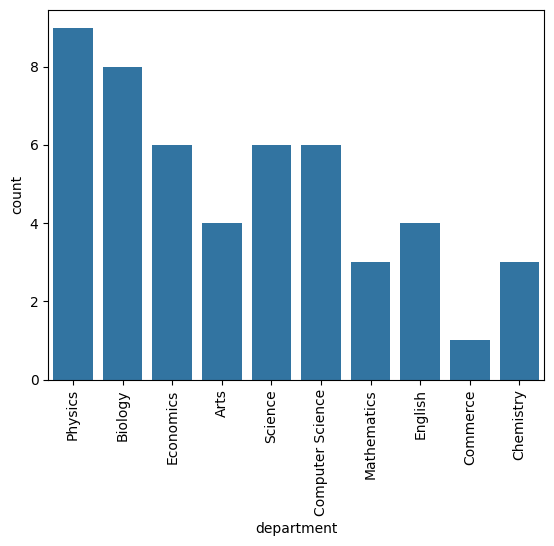

In [14]:
plt.xticks(rotation=90)
sns.countplot(data=data,x='department')

# Question 10: [ Marks 10 ]

create a scatter plot showing attendance vs score.

* Color the points by department
* Add a title: "Attendance vs Score by Department"
* Label X-axis as "Attendance (%)" and Y-axis as "Score"
* Display the chart

Text(0, 0.5, 'Score')

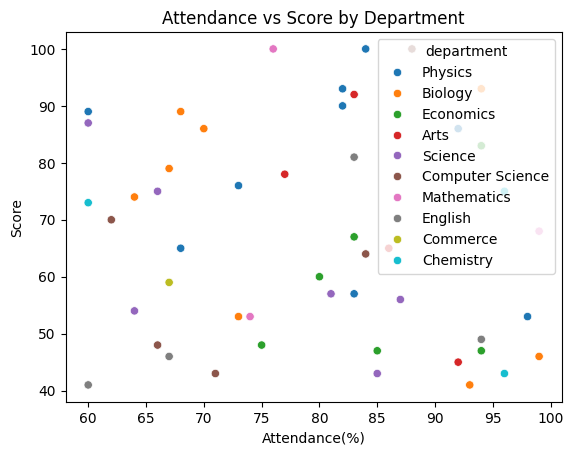

In [15]:
sns.scatterplot(data=data, x='attendance',y='score',hue='department')
plt.title('Attendance vs Score by Department')
plt.xlabel('Attendance(%)')
plt.ylabel('Score')